<a href="https://colab.research.google.com/github/NoraSedighi/AI-HW-Week2/blob/master/AI_CNN_FairFace_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

print(os.listdir('/content/drive/MyDrive/AI_CNN_FairFace_Project'))

['fairface_dataset.rar']


In [5]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:7.0.7-1build1).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.


In [6]:
!unrar x "/content/drive/MyDrive/AI_CNN_FairFace_Project/fairface_dataset.rar" "/content/fairface_dataset/"

Streaming output truncated to the last 5000 lines.
Extracting  /content/fairface_dataset/train/8357.jpg                      94%  OK 
Extracting  /content/fairface_dataset/train/83570.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83571.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83572.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83573.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83574.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83575.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83576.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83577.jpg                     94%  OK 
Extracting  /content/fairface_dataset/train/83578.jpg                     94%  OK 
Extracting  /content/fairface

In [7]:
import os

print(os.listdir('/content/fairface_dataset'))

['val', 'fairface-label-val.csv', 'train', 'fairface-label-train.csv']


In [8]:
train_path = '/content/fairface_dataset/train'

print('Number of train images:', len(os.listdir(train_path)))

Number of train images: 86744


In [9]:
val_path = '/content/fairface_dataset/val'

print('Number of validation images:', len(os.listdir(val_path)))

Number of validation images: 10954


In [10]:
import pandas as pd

train_csv_path = '/content/fairface_dataset/fairface-label-train.csv'
val_csv_path = '/content/fairface_dataset/fairface-label-val.csv'

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (86744, 5)
Validation shape: (10954, 5)


In [11]:
print(train_df.head())

          file  age  gender        race  service_test
0  train/1.jpg   59    Male  East Asian          True
1  train/2.jpg   39  Female      Indian         False
2  train/3.jpg   11  Female       Black         False
3  train/4.jpg   26  Female      Indian          True
4  train/5.jpg   26  Female      Indian          True


In [12]:
print(train_df.columns)

Index(['file', 'age', 'gender', 'race', 'service_test'], dtype='object')


In [13]:
print(train_df['race'].unique())

['East Asian' 'Indian' 'Black' 'White' 'Middle Eastern' 'Latino_Hispanic'
 'Southeast Asian']


In [14]:
print(train_df['race'].value_counts())

race
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64


In [15]:
race_distribution = train_df['race'].value_counts(normalize=True) * 100

print(race_distribution)

race
White              19.052615
Latino_Hispanic    15.409711
Indian             14.201559
East Asian         14.164668
Black              14.102416
Southeast Asian    12.444665
Middle Eastern     10.624366
Name: proportion, dtype: float64


In [16]:
print(val_df['race'].value_counts())

race
White              2085
Latino_Hispanic    1623
Black              1556
East Asian         1550
Indian             1516
Southeast Asian    1415
Middle Eastern     1209
Name: count, dtype: int64


In [17]:
print(val_df['race'].value_counts(normalize=True) * 100)

race
White              19.034143
Latino_Hispanic    14.816505
Black              14.204857
East Asian         14.150082
Indian             13.839693
Southeast Asian    12.917656
Middle Eastern     11.037064
Name: proportion, dtype: float64


In [18]:
train_missing = 0

for file_name in train_df['file']:
    file_path = '/content/fairface_dataset/' + file_name

    if not os.path.exists(file_path):
        train_missing += 1

print("Missing train images:", train_missing)

Missing train images: 0


In [19]:
val_missing = 0

for file_name in val_df['file']:
    file_path = '/content/fairface_dataset/' + file_name

    if not os.path.exists(file_path):
        val_missing += 1

print("Missing validation images:", val_missing)

Missing validation images: 0


**Create DataSet and DataLoader**

In [20]:
race_names = sorted(train_df['race'].unique())

race_to_label = {
    race: index
    for index, race in enumerate(race_names)
}

label_to_race = {
    index: race
    for race, index in race_to_label.items()
}

print(race_to_label)

{'Black': 0, 'East Asian': 1, 'Indian': 2, 'Latino_Hispanic': 3, 'Middle Eastern': 4, 'Southeast Asian': 5, 'White': 6}


In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [22]:
from torch.utils.data import Dataset
from PIL import Image
import os

class FairFaceDataset(Dataset):

    def __init__(self, dataframe, image_folder, race_to_label, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_folder = image_folder
        self.race_to_label = race_to_label
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_name = self.dataframe.iloc[index]['file']
        race_name = self.dataframe.iloc[index]['race']

        image_path = os.path.join(
            self.image_folder,
            image_name
        )

        image = Image.open(image_path).convert('RGB')

        label = self.race_to_label[race_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [23]:
train_dataset = FairFaceDataset(
    train_df,
    '/content/fairface_dataset',
    race_to_label,
    train_transform
)

val_dataset = FairFaceDataset(
    val_df,
    '/content/fairface_dataset',
    race_to_label,
    val_transform
)

In [24]:
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 86744
Validation dataset size: 10954


In [25]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Race:", label_to_race[label])

Image shape: torch.Size([3, 128, 128])
Label: 1
Race: East Asian


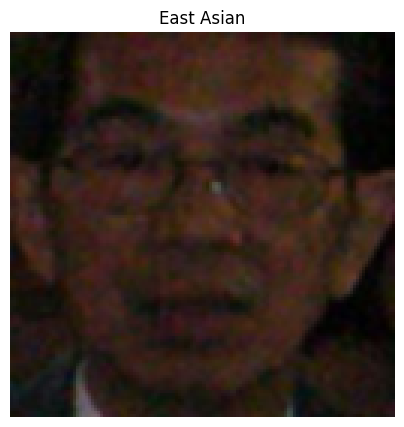

In [26]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

image = image.permute(1, 2, 0)

image = image * 0.5 + 0.5

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(label_to_race[label])
plt.axis('off')
plt.show()

In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

In [28]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])


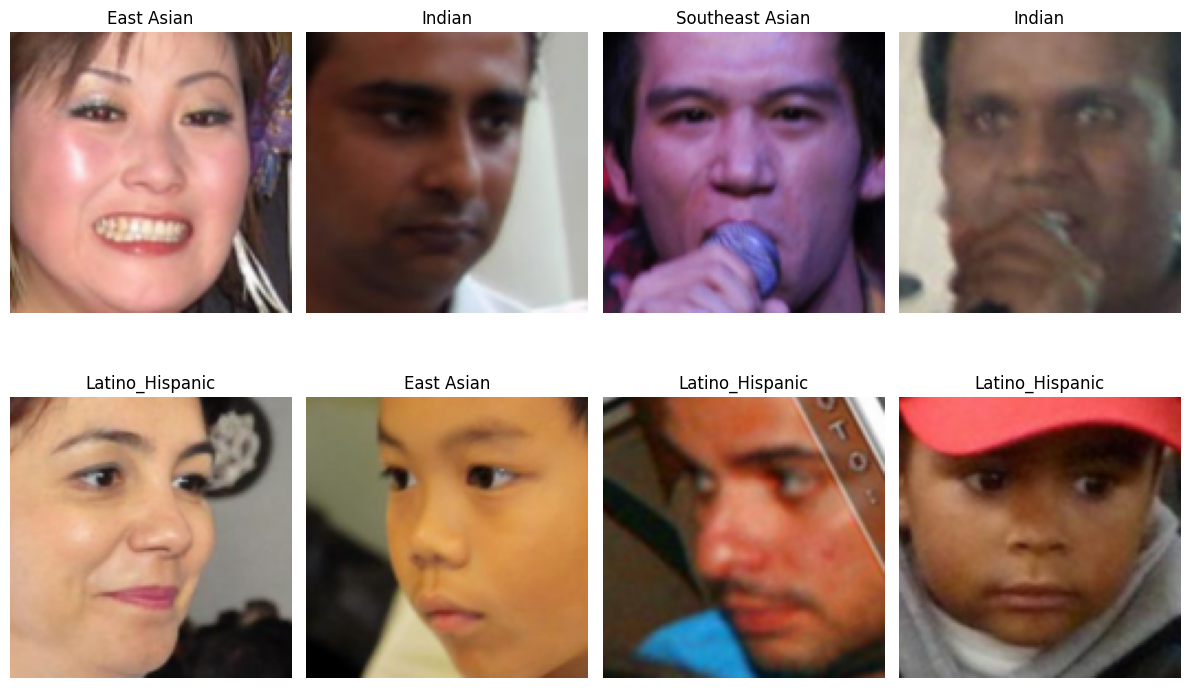

In [29]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):

    image = images[i].permute(1, 2, 0)

    image = image * 0.5 + 0.5

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(label_to_race[labels[i].item()])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Create CNN**

In [31]:
import torch
import torch.nn as nn


class CNN(nn.Module):

    def __init__(self, num_classes):

        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # Convolutional Layer 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolutional Layer 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolutional Layer 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [32]:
num_classes = train_df['race'].nunique()

print("Number of classes:", num_classes)

Number of classes: 7


In [33]:
model = CNN(num_classes)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [35]:
model = model.to(device)

In [36]:
criterion = nn.CrossEntropyLoss()

In [37]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [38]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 128, 128])
Output shape: torch.Size([64, 7])


**Training Loop**

In [39]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Save loss
        total_loss += loss.item()

        # Calculate accuracy
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(train_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [40]:
def evaluate(model, val_loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / len(val_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [41]:
num_epochs = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 1.6014 Train Accuracy: 0.3782 Val Loss: 1.3846 Val Accuracy: 0.4764
Epoch [2/10] Train Loss: 1.3612 Train Accuracy: 0.4748 Val Loss: 1.2545 Val Accuracy: 0.5209
Epoch [3/10] Train Loss: 1.2710 Train Accuracy: 0.5109 Val Loss: 1.2004 Val Accuracy: 0.5353
Epoch [4/10] Train Loss: 1.2152 Train Accuracy: 0.5317 Val Loss: 1.1675 Val Accuracy: 0.5553
Epoch [5/10] Train Loss: 1.1789 Train Accuracy: 0.5465 Val Loss: 1.1706 Val Accuracy: 0.5526
Epoch [6/10] Train Loss: 1.1436 Train Accuracy: 0.5604 Val Loss: 1.1377 Val Accuracy: 0.5665
Epoch [7/10] Train Loss: 1.1099 Train Accuracy: 0.5740 Val Loss: 1.1278 Val Accuracy: 0.5708
Epoch [8/10] Train Loss: 1.0777 Train Accuracy: 0.5858 Val Loss: 1.1388 Val Accuracy: 0.5667
Epoch [9/10] Train Loss: 1.0560 Train Accuracy: 0.5951 Val Loss: 1.1522 Val Accuracy: 0.5663
Epoch [10/10] Train Loss: 1.0251 Train Accuracy: 0.6056 Val Loss: 1.1330 Val Accuracy: 0.5736


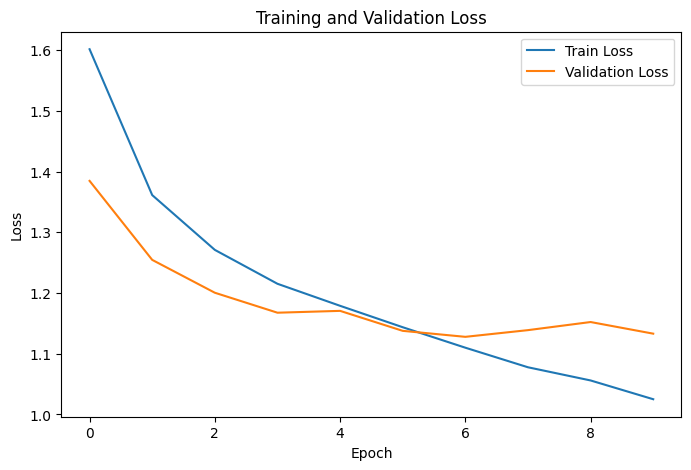

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()

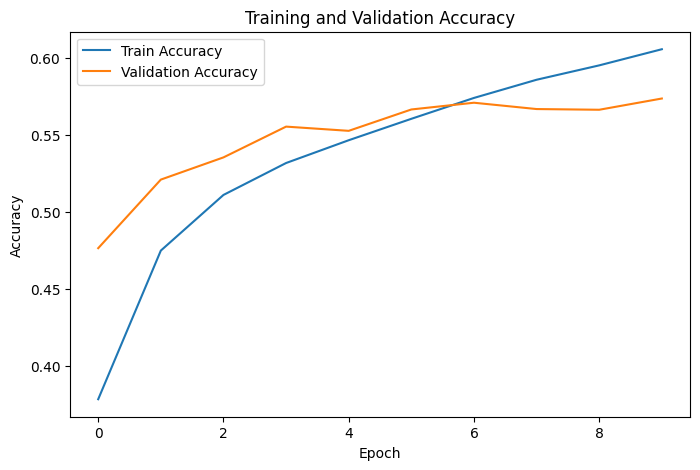

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.show()

In [44]:
best_epoch = val_accuracies.index(max(val_accuracies)) + 1
best_val_accuracy = max(val_accuracies)

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 10
Best Validation Accuracy: 0.5735804272411904


**Confusion Matrix**

In [45]:
from sklearn.metrics import confusion_matrix

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [46]:
print("Number of labels:", len(all_labels))
print("Number of predictions:", len(all_predictions))

Number of labels: 10954
Number of predictions: 10954


In [47]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[1092   16  203  110   25   57   53]
 [  19 1056   34   44   35  223  139]
 [  95   29  961  189  118   61   63]
 [  56   82  245  669  178  101  292]
 [  29   28  107  219  512   15  299]
 [  57  366  101  143   28  630   90]
 [  34   94   79  208  279   28 1363]]


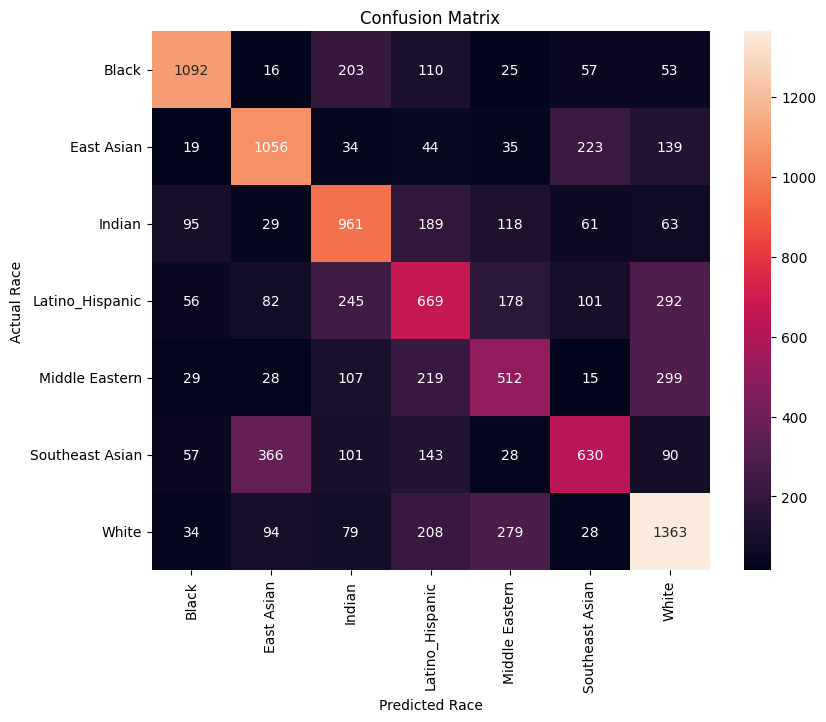

In [48]:
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=race_names,
    yticklabels=race_names
)

plt.xlabel('Predicted Race')
plt.ylabel('Actual Race')
plt.title('Confusion Matrix')

plt.show()

**Classification Report**

In [49]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=race_names
)

print(report)

                 precision    recall  f1-score   support

          Black       0.79      0.70      0.74      1556
     East Asian       0.63      0.68      0.66      1550
         Indian       0.56      0.63      0.59      1516
Latino_Hispanic       0.42      0.41      0.42      1623
 Middle Eastern       0.44      0.42      0.43      1209
Southeast Asian       0.57      0.45      0.50      1415
          White       0.59      0.65      0.62      2085

       accuracy                           0.57     10954
      macro avg       0.57      0.56      0.57     10954
   weighted avg       0.58      0.57      0.57     10954



**Model Evaluation and Results**

After training the CNN model for 10 epochs, the model was evaluated on the validation dataset containing 10,954 images. The final validation accuracy was approximately 57.36%. The training accuracy reached 60.56%, while the validation accuracy remained lower, indicating a moderate generalization gap between the training and validation data.

The validation loss decreased substantially during the first several epochs and reached its lowest value around the middle of training. After that point, the validation loss showed some fluctuations, while the training loss continued to decrease. This behavior suggests that the model continued to learn the training data, while improvements on unseen validation images became more limited.

**Confusion Matrix Analysis**

The confusion matrix provides more detailed information about the model's behavior across the seven classes. The diagonal elements represent correctly classified samples, while the off-diagonal elements represent misclassifications.

The model achieved relatively stronger results for some classes. For example, the Black class obtained a precision of 0.79, recall of 0.70, and F1-score of 0.74. This indicates that the model was comparatively more consistent for this class.

The East Asian class also achieved relatively balanced results, with a precision of 0.63, recall of 0.68, and F1-score of 0.66. The White class had a recall of 0.65 and an F1-score of 0.62.

On the other hand, the results were weaker for Latino_Hispanic and Middle Eastern. Latino_Hispanic achieved a precision of 0.42, recall of 0.41, and F1-score of 0.42, while Middle Eastern achieved a precision of 0.44, recall of 0.42, and F1-score of 0.43.

The confusion matrix also shows that several classes were frequently confused with one another. For example, a considerable number of samples from the Latino_Hispanic, Middle Eastern, Southeast Asian, and White classes were assigned to other classes. This indicates that the classification task contains substantial overlap between some classes from the perspective of the learned visual features.

**Overall Performance**

The overall accuracy was 57%, while the macro-average F1-score was also approximately 0.57. The weighted-average F1-score was 0.57.

The relatively similar macro and weighted averages indicate that the overall performance was not dominated solely by the larger classes. However, the differences between individual class F1-scores show that the model did not perform equally across all classes.

Overall, the results demonstrate that the CNN was able to learn meaningful visual patterns from the training data, but its performance on unseen data was moderate and varied considerably across classes.

**Possible Improvements**

Several approaches could potentially improve the performance of the model in a future experiment. These include experimenting with different CNN architectures, applying more suitable data augmentation techniques, tuning the learning rate and batch size, increasing the input image resolution, and using transfer learning with a pretrained image model. Regularization techniques such as dropout and weight decay could also be investigated